In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTEENN


In [4]:
df = pd.read_csv(r"D:\creditpathAI\datasets\Loan_Default-1.csv")
df.head()


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


**Check missing values**

In [5]:
df.isnull().sum()


ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [6]:
print("Shape:", df.shape)


Shape: (148670, 34)


**Visualize missing values**

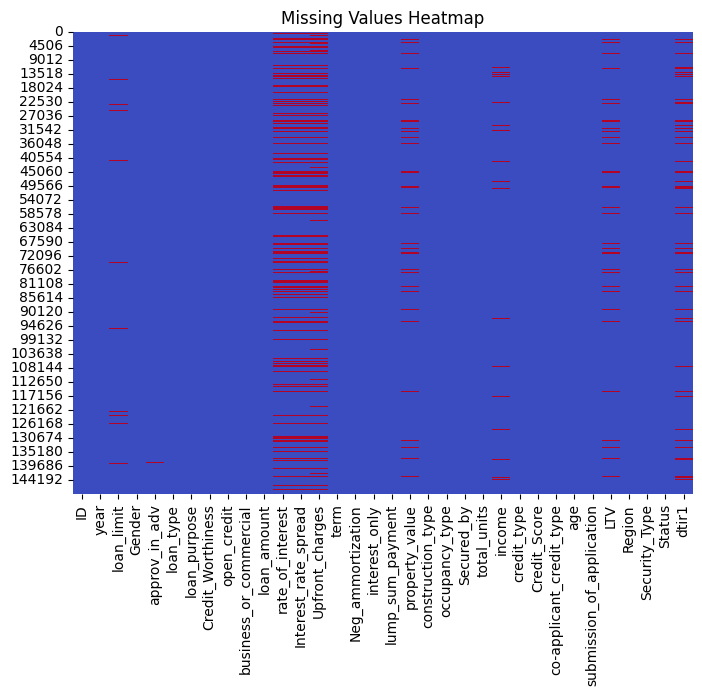

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()


In [8]:
# Fill categorical columns with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())


**Encode categorical variables**

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


**Check target variable distribution (before balancing)**

C:\Users\kattu\AppData\Local\Temp\ipykernel_15800\1234801432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Status", data=df, palette="Set2")


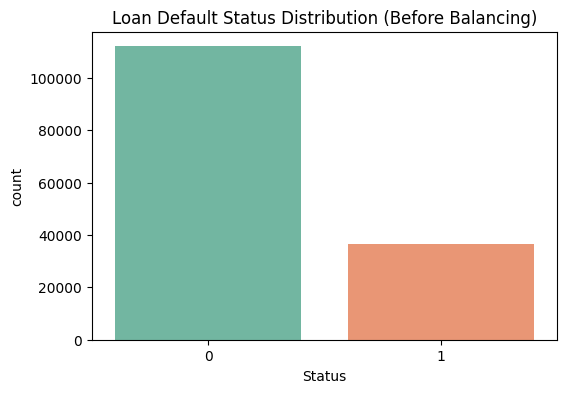

Status
0    112031
1     36639
Name: count, dtype: int64

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Status", data=df, palette="Set2")
plt.title("Loan Default Status Distribution (Before Balancing)")
plt.show()

df["Status"].value_counts()


**Train-Test Split**

In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Scale features**

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Balance dataset (SMOTEENN)**

In [13]:
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())


Before balancing:
 Status
0    89625
1    29311
Name: count, dtype: int64

After balancing:
 Status
1    85492
0    66838
Name: count, dtype: int64


**Visualize target distribution after balancing**

C:\Users\kattu\AppData\Local\Temp\ipykernel_15800\951294466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="Set1")


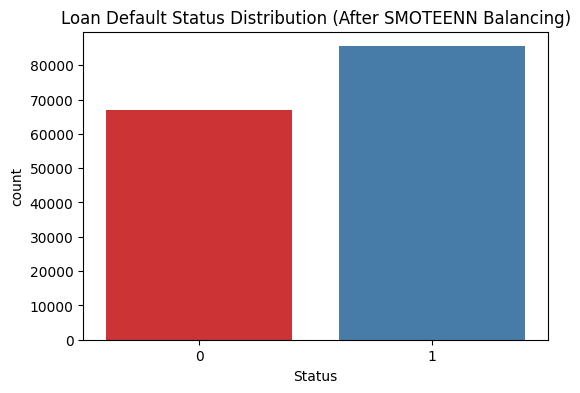

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled, palette="Set1")
plt.title("Loan Default Status Distribution (After SMOTEENN Balancing)")
plt.show()


**Correlation heatmap**

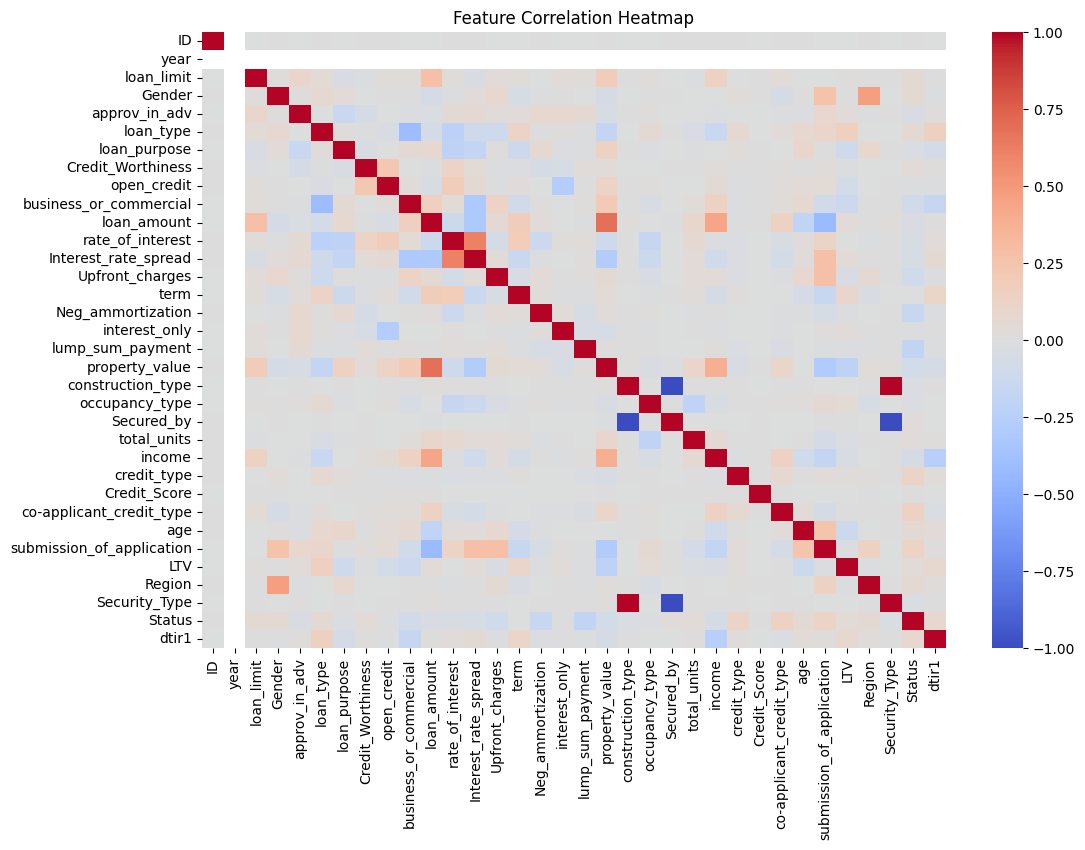

In [15]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


**Distribution of numerical features**

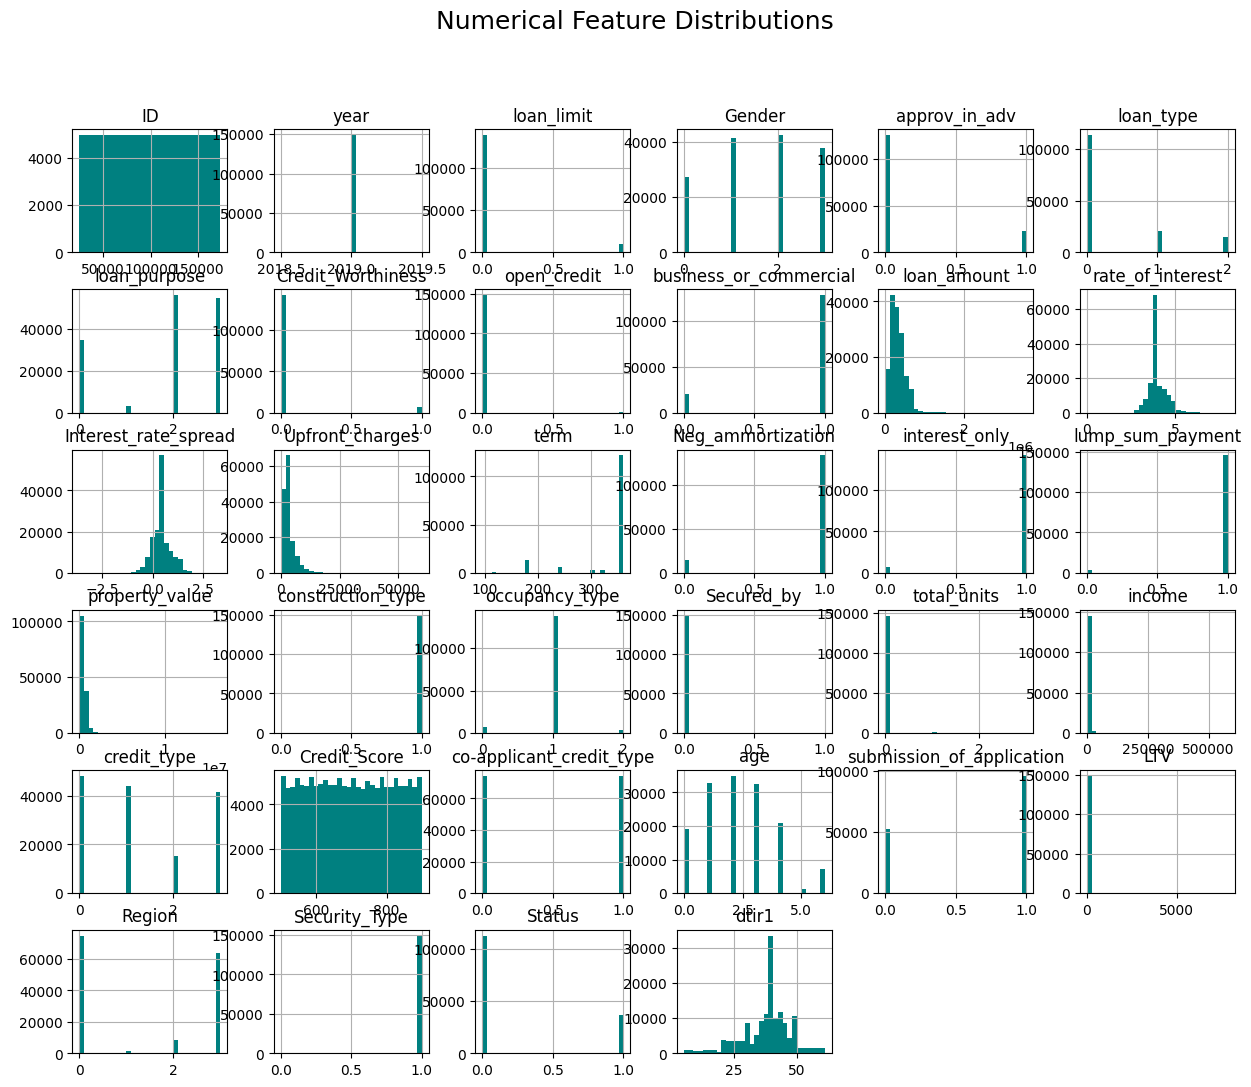

In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(bins=30, figsize=(15,12), color="teal")
plt.suptitle("Numerical Feature Distributions", size=18)
plt.show()


**Boxplots for outlier detection**

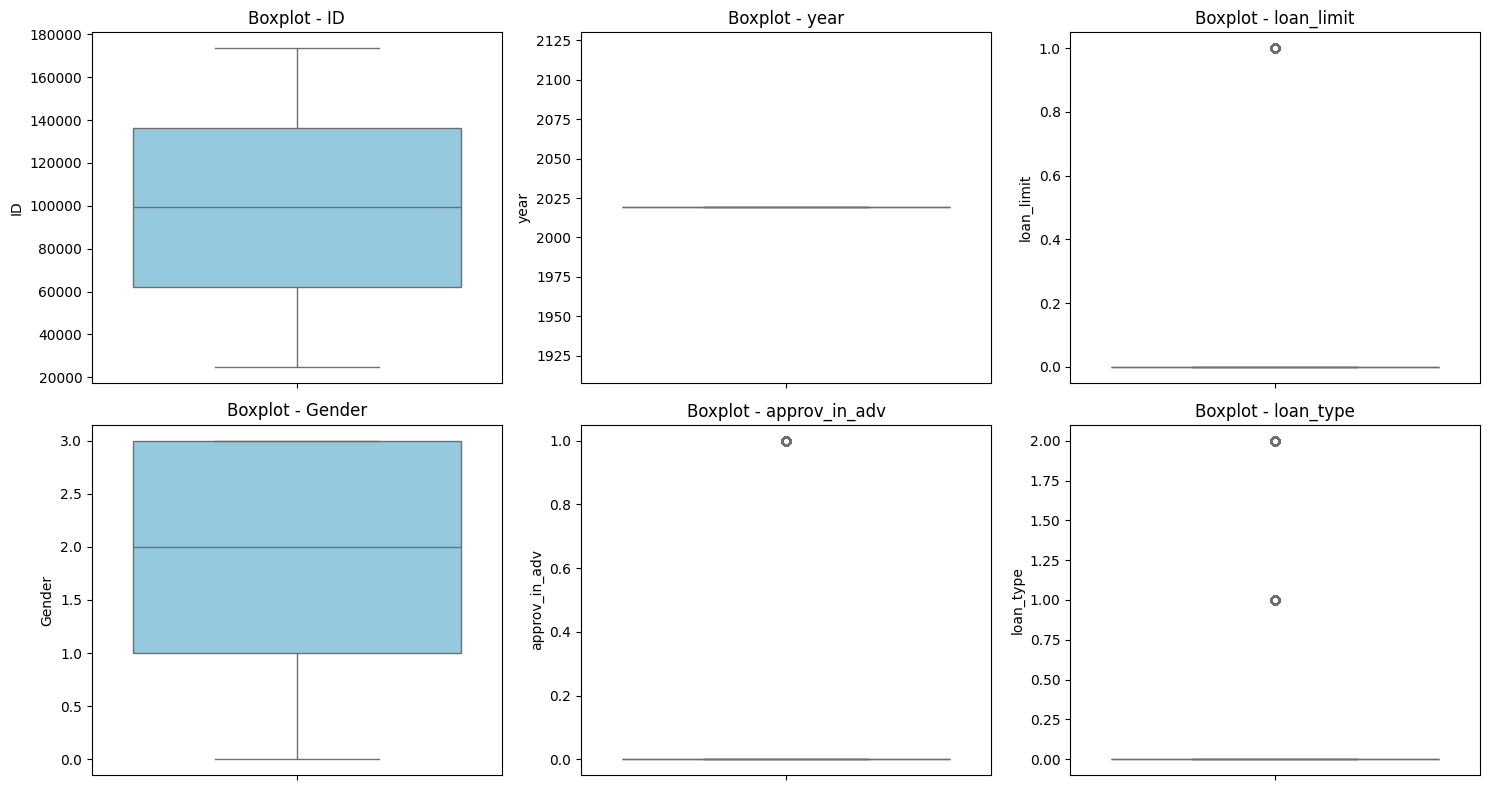

In [17]:
plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols[:6], 1):   # first 6 numerical features
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()


In [18]:
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87     22406
           1       0.66      0.27      0.38      7328

    accuracy                           0.79     29734
   macro avg       0.73      0.61      0.63     29734
weighted avg       0.76      0.79      0.75     29734



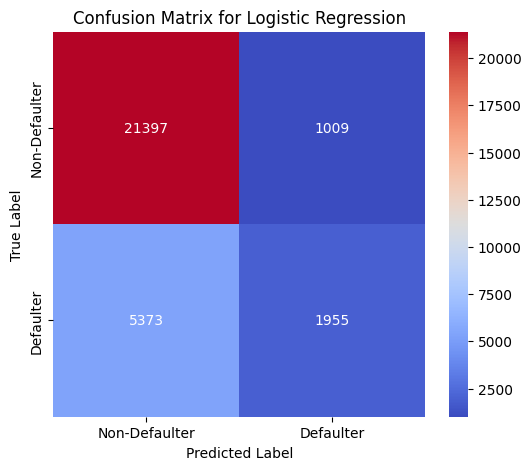

--------------------------------------------------

--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



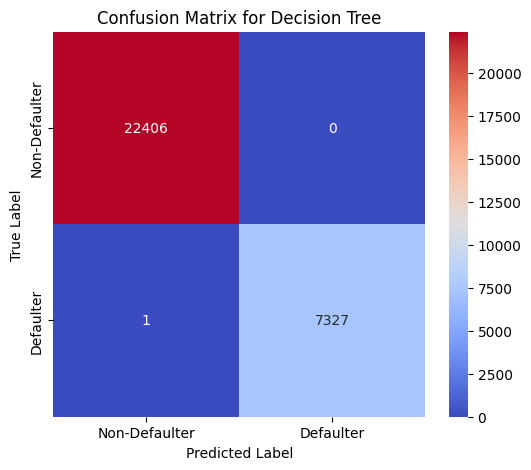

--------------------------------------------------

--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



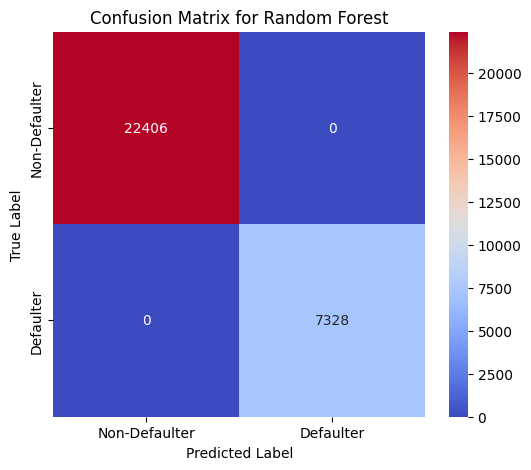

--------------------------------------------------

--- Evaluation for XGBoost ---


c:\Users\kattu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:35:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



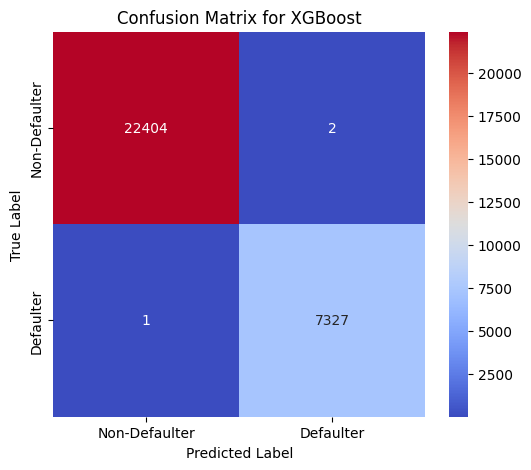

--------------------------------------------------

--- Evaluation for KNN ---
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     22406
           1       0.78      0.81      0.79      7328

    accuracy                           0.90     29734
   macro avg       0.86      0.87      0.86     29734
weighted avg       0.90      0.90      0.90     29734



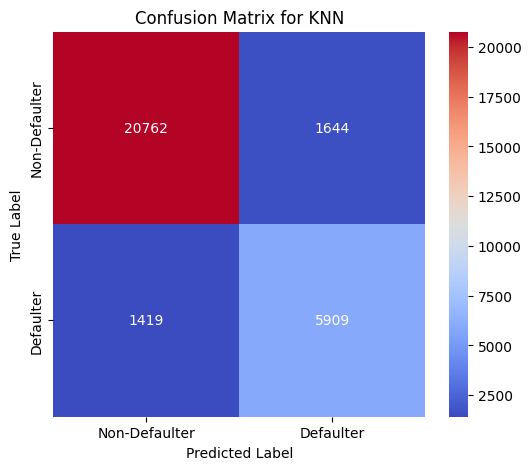

--------------------------------------------------

--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87     22406
           1       1.00      0.09      0.16      7328

    accuracy                           0.77     29734
   macro avg       0.88      0.54      0.51     29734
weighted avg       0.83      0.77      0.69     29734



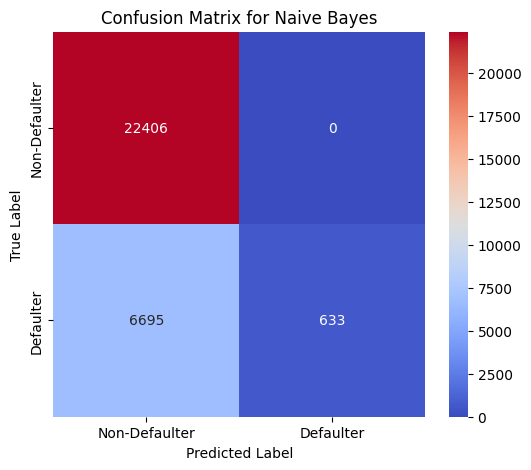

--------------------------------------------------

--- Evaluation for Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



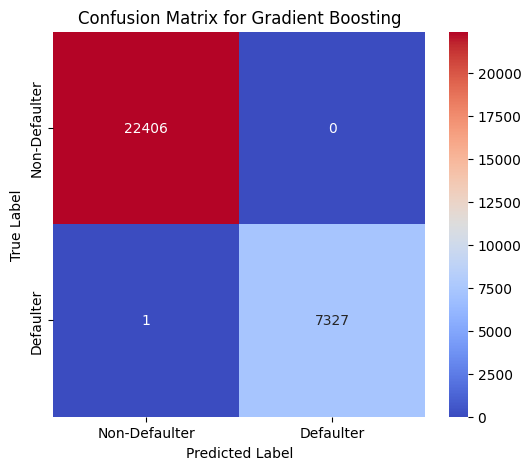

--------------------------------------------------


In [19]:

# --- Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    #"SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}

# --- Train/Validation split ---
X_train_full, X_valid, y_train_full, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# --- Dictionary to store results ---
results = {}

# --- Train and Evaluate Each Model ---
for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")

    # Train on training data
    model.fit(X_train_full, y_train_full)

    # Predictions
    y_train_pred = model.predict(X_train_full)
    y_valid_pred = model.predict(X_valid)
    y_test_pred = model.predict(X_test)

    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    train_acc = accuracy_score(y_train_full, y_train_pred)
    val_acc = accuracy_score(y_valid, y_valid_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    sensitivity = recall_score(y_test, y_test_pred)
    specificity = tn / (tn + fp)
    precision = precision_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None

    # Save in dictionary
    results[name] = {
        "Train Acc": train_acc,
        "Validation Acc": val_acc,
        "Test Acc": test_acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-Score": f1,
        "AUC": auc
    }

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Non-Defaulter', 'Defaulter'],
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("-" * 50)




--- Final Model Comparison ---
                     Train Acc  Validation Acc  Test Acc  Sensitivity  \
Random Forest         1.000000        0.999958  1.000000     1.000000   
Decision Tree         1.000000        0.999916  0.999966     0.999864   
Gradient Boosting     1.000000        0.999916  0.999966     0.999864   
XGBoost               1.000000        0.999958  0.999899     0.999864   
KNN                   0.932043        0.894232  0.896987     0.806359   
Logistic Regression   0.782802        0.780267  0.785364     0.266785   
Naive Bayes           0.772018        0.772280  0.774837     0.086381   

                     Specificity  Precision  F1-Score       AUC  
Random Forest           1.000000   1.000000  1.000000  1.000000  
Decision Tree           1.000000   1.000000  0.999932  0.999932  
Gradient Boosting       1.000000   1.000000  0.999932  1.000000  
XGBoost                 0.999911   0.999727  0.999795  0.999993  
KNN                     0.926627   0.782338  0.794167

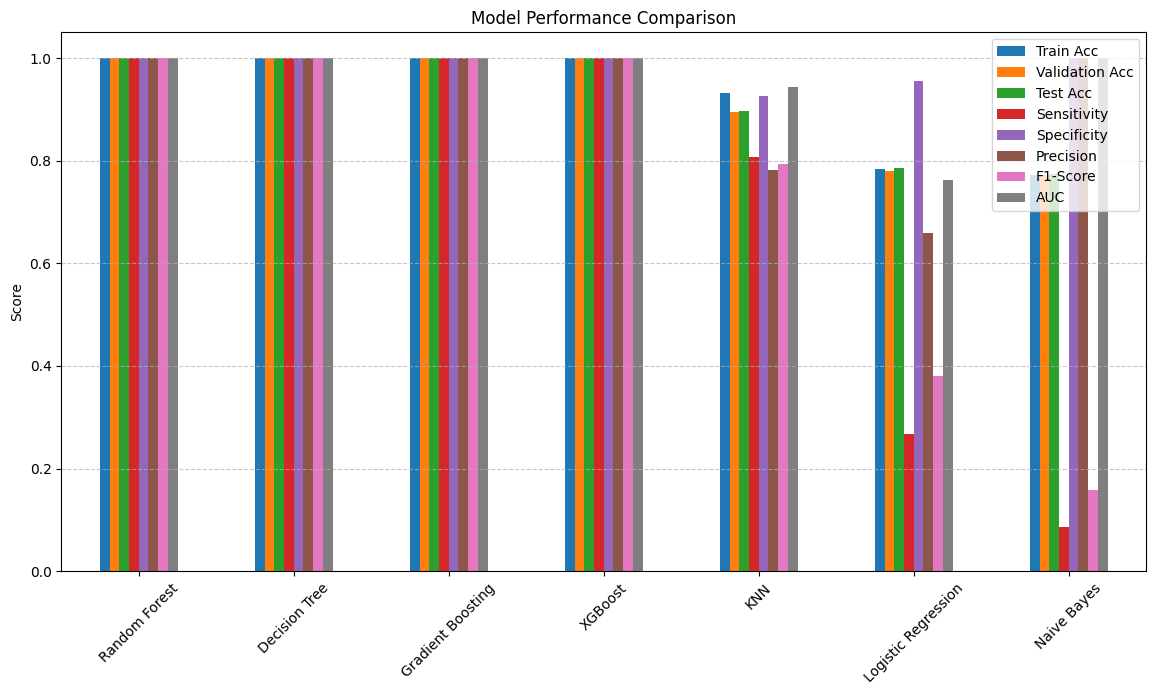

In [20]:
# --- Final Comparison ---
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='Test Acc', ascending=False)

print("\n--- Final Model Comparison ---")
print(results_df)

# --- Export to LaTeX with Multi-column Header ---
latex_table = results_df.rename(columns={
    "Train Acc": "Train",
    "Validation Acc": "Validation",
    "Test Acc": "Test"
}).to_latex(
    index=True, float_format="%.4f", multirow=True, 
    column_format="lccc|cccccc",  # group cols
    header=["Train", "Validation", "Test", "Sensitivity", "Specificity", "Precision", "F1-Score", "AUC"]
)

print("\n--- LaTeX Table ---")
print(latex_table)

# --- Plot the results ---
results_df.plot(kind='bar', figsize=(14, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
